# Prévision globale des quantités mensuelles par LSTM

## Objectif

Cette expérimentation vise à évaluer la faisabilité d'un réseau de neurones récurrent de type Long Short-Term Memory (LSTM) pour la prévision mensuelle des quantités livrées.

Contrairement aux modèles Random Forest et XGBoost qui utilisent des variables explicatives construites (lags, moyennes mobiles, variables calendaires), le LSTM possède la capacité d'apprendre automatiquement les dépendances temporelles présentes dans les séries chronologiques.

L'objectif n'est pas nécessairement d'obtenir le meilleur modèle, mais d'étudier si une architecture Deep Learning est adaptée au contexte de l'entreprise.

Afin de garantir une comparaison équitable avec les autres modèles, le même découpage temporel (80 % apprentissage / 20 % test) est conservé.

In [368]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

import joblib

np.random.seed(42)
tf.random.set_seed(42)

print("Tensorflow :", tf.__version__)

Tensorflow : 2.21.0


In [370]:
df = pd.read_csv("../data/propre/dataset_ml_mensuel.csv")

print(df.shape)

df.head()

(5473, 24)


,Code Station,N° article,mois_periode,quantite_mois,nb_commandes,mois,annee,num_mois,trimestre,mois_sin,...,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,StationEncoded,ProduitEncoded
0,ST0001,A0001,2023-10,79000,4,2023-10-01,2023,10,4,-8.660254e-01,...,20000.0,95000.0,20000.0,65000.000000,68833.333333,57166.666667,39686.269666,1.1370,0,0
1,ST0001,A0001,2023-11,70000,4,2023-11-01,2023,11,4,-5.000000e-01,...,79000.0,80000.0,24000.0,59666.666667,74000.000000,62083.333333,34355.979586,0.9611,0,0
2,ST0001,A0001,2023-12,55000,4,2023-12-01,2023,12,4,-2.449294e-16,...,70000.0,20000.0,49000.0,56333.333333,68166.666667,65916.666667,31785.741038,0.8546,0,0
3,ST0001,A0001,2024-01,55000,5,2024-01-01,2024,1,1,5.000000e-01,...,55000.0,79000.0,56000.0,68000.000000,66500.000000,66416.666667,12124.355653,1.0238,0,0
4,ST0001,A0001,2024-02,105000,7,2024-02-01,2024,2,1,8.660254e-01,...,55000.0,70000.0,34000.0,60000.000000,59833.333333,66333.333333,8660.254038,0.9045,0,0


In [372]:
# ============================================================
# FILTRAGE DES COUPLES
# ============================================================

print("="*70)
print("FILTRAGE DES COUPLES")
print("="*70)

nb_mois = (
    df.groupby(
        ["Code Station","N° article"]
    )["quantite_mois"]
    .count()
    .reset_index(name="nb_mois")
)

couples_valides = nb_mois[
    nb_mois["nb_mois"]>=12
][["Code Station","N° article"]]

df = df.merge(
    couples_valides,
    on=["Code Station","N° article"],
    how="inner"
)

print("Dataset filtré :",df.shape)

print()

print(
    "Nombre de couples :",
    df[
        ["Code Station","N° article"]
    ].drop_duplicates().shape[0]
)

FILTRAGE DES COUPLES
Dataset filtré : (5338, 24)

Nombre de couples : 147


In [374]:
df["mois"] = pd.to_datetime(df["mois"])

df = df.sort_values(
    [
        "Code Station",
        "N° article",
        "mois"
    ]
)

df.reset_index(
    drop=True,
    inplace=True
)

df.head()

,Code Station,N° article,mois_periode,quantite_mois,nb_commandes,mois,annee,num_mois,trimestre,mois_sin,...,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,StationEncoded,ProduitEncoded
0,ST0001,A0001,2023-10,79000,4,2023-10-01,2023,10,4,-8.660254e-01,...,20000.0,95000.0,20000.0,65000.000000,68833.333333,57166.666667,39686.269666,1.1370,0,0
1,ST0001,A0001,2023-11,70000,4,2023-11-01,2023,11,4,-5.000000e-01,...,79000.0,80000.0,24000.0,59666.666667,74000.000000,62083.333333,34355.979586,0.9611,0,0
2,ST0001,A0001,2023-12,55000,4,2023-12-01,2023,12,4,-2.449294e-16,...,70000.0,20000.0,49000.0,56333.333333,68166.666667,65916.666667,31785.741038,0.8546,0,0
3,ST0001,A0001,2024-01,55000,5,2024-01-01,2024,1,1,5.000000e-01,...,55000.0,79000.0,56000.0,68000.000000,66500.000000,66416.666667,12124.355653,1.0238,0,0
4,ST0001,A0001,2024-02,105000,7,2024-02-01,2024,2,1,8.660254e-01,...,55000.0,70000.0,34000.0,60000.000000,59833.333333,66333.333333,8660.254038,0.9045,0,0


In [376]:
features = [

'StationEncoded',

'ProduitEncoded',

'annee',

'num_mois',

'trimestre',

'mois_sin',

'mois_cos',

'saison_benin',

'Lag_1',

'Lag_3',

'Lag_12',

'Rolling_3m',

'Rolling_6m',

'Rolling_12m',

'Rolling_Std_3m',

'ratio_tendance',

'nb_commandes'

]

target = "quantite_mois"

In [378]:
# Vérification des séries

resume = (
    df
    .groupby(["Code Station","N° article"])
    .agg(
        debut=("mois","min"),
        fin=("mois","max"),
        observations=("quantite_mois","count")
    )
    .reset_index()
)

display(resume.head())

print()

print(resume["observations"].describe())

print()

print("Minimum :",resume["observations"].min())

print("Maximum :",resume["observations"].max())

print("Moyenne :",round(resume["observations"].mean(),2))

,Code Station,N° article,debut,fin,observations
0,ST0001,A0001,2023-10-01,2025-12-01,27
1,ST0001,A0002,2023-10-01,2025-12-01,26
2,ST0002,A0001,2021-03-01,2025-12-01,58
3,ST0002,A0002,2021-03-01,2025-12-01,55
4,ST0003,A0001,2021-03-01,2025-12-01,56



count    147.000000
mean      36.312925
std       16.037543
min       12.000000
25%       21.500000
50%       34.000000
75%       52.000000
max       60.000000
Name: observations, dtype: float64

Minimum : 12
Maximum : 60
Moyenne : 36.31


## 6. Normalisation des variables

Les réseaux de neurones sont sensibles à l'échelle des variables d'entrée.

Contrairement aux modèles basés sur les arbres (Random Forest et XGBoost), le LSTM repose sur des opérations de gradient. Une normalisation des variables permet :

- d'améliorer la stabilité numérique ;
- d'accélérer la convergence ;
- d'éviter qu'une variable domine les autres par son ordre de grandeur.

Le MinMaxScaler est retenu car il projette les variables dans l'intervalle [0,1], ce qui est adapté aux fonctions d'activation utilisées par le LSTM.

In [380]:
series_normalisees = {}

for (station, produit), groupe in df.groupby(
    ["Code Station","N° article"]
):

    groupe = groupe.sort_values("mois").copy()

    scaler = MinMaxScaler()

    groupe["quantite_norm"] = scaler.fit_transform(
        groupe[["quantite_mois"]]
    )

    series_normalisees[(station,produit)] = {
        "data":groupe,
        "scaler":scaler
    }

print("Nombre de séries normalisées :",len(series_normalisees))

Nombre de séries normalisées : 147


## 7. Construction des fenêtres glissantes
### Justification scientifique

Le LSTM ne reçoit pas une série complète en entrée mais une succession de fenêtres temporelles de longueur fixe. Chaque fenêtre de 12 mois sert à prédire le mois suivant.  

Ainsi, une série de 60 mois génère :  

fenêtre 1 → mois 1 à 12 → prédire le mois 13  
fenêtre 2 → mois 2 à 13 → prédire le mois 14  
...
fenêtre 48 → mois 48 à 59 → prédire le mois 60  

Une seule série produit donc plusieurs exemples d'apprentissage, ce qui augmente considérablement le volume de données disponible pour entraîner un modèle global.  

In [382]:
WINDOW_SIZE = 12

X = []
y = []

meta = []

for (station, produit), infos in series_normalisees.items():

    serie = infos["data"]["quantite_norm"].values

    dates = infos["data"]["mois"].values

    for i in range(len(serie) - WINDOW_SIZE):

        X.append(
            serie[i:i+WINDOW_SIZE]
        )

        y.append(
            serie[i+WINDOW_SIZE]
        )

        meta.append({

            "Code Station":station,

            "N° article":produit,

            "Date":dates[i+WINDOW_SIZE]

        })

X = np.array(X)

y = np.array(y)

meta = pd.DataFrame(meta)

print("="*70)
print("JEU D'APPRENTISSAGE")
print("="*70)

print("Nombre de fenêtres :",len(X))
print("Dimension X :",X.shape)
print("Dimension y :",y.shape)

JEU D'APPRENTISSAGE
Nombre de fenêtres : 3574
Dimension X : (3574, 12)
Dimension y : (3574,)


In [384]:
# Reshape pour le LSTM


X = X.reshape(

    X.shape[0],

    X.shape[1],

    1

)

print(X.shape)

(3574, 12, 1)


## 8. Découpage temporel des données

Afin d'assurer une évaluation réaliste des performances, le découpage respecte l'ordre chronologique des observations.

Les 80 premiers pour cent des observations sont utilisés pour l'apprentissage tandis que les 20 derniers pour cent servent à l'évaluation.

Aucun mélange aléatoire (shuffle) n'est effectué afin d'éviter toute fuite d'information temporelle.

In [386]:
ordre = np.argsort(meta["Date"])

X = X[ordre]

y = y[ordre]

meta = meta.iloc[ordre].reset_index(drop=True)

split = int(len(X)*0.80)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

meta_train = meta.iloc[:split]
meta_test = meta.iloc[split:]

print("="*70)
print("TRAIN / TEST")
print("="*70)

print("Train :",X_train.shape)

print("Test  :",X_test.shape)

TRAIN / TEST
Train : (2859, 12, 1)
Test  : (715, 12, 1)


## 9. Architecture du réseau LSTM

Le modèle proposé comporte :

- deux couches LSTM permettant l'apprentissage des dépendances temporelles ;
- des couches Dropout limitant le surapprentissage ;
- une couche Dense finale produisant la prévision de la quantité mensuelle.

L'optimiseur Adam est retenu en raison de sa robustesse pour les séries temporelles.

In [388]:
# MODELE LSTM

model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(WINDOW_SIZE,1)
    ),

    Dropout(0.20),

    LSTM(
        32
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])

model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                       │ (None, 12, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_19 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Entraînement

Deux mécanismes sont utilisés afin d'améliorer l'apprentissage :

- EarlyStopping : arrêt automatique lorsque la performance sur le jeu de validation ne progresse plus ;
- ReduceLROnPlateau : diminution automatique du taux d'apprentissage lorsque la convergence ralentit.

In [390]:
# CALLBACKS

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5

)

history = model.fit(

    X_train,

    y_train,

    validation_data=(

        X_test,

        y_test

    ),

    epochs=100,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0635 - mae: 0.1845 - val_loss: 0.0412 - val_mae: 0.1509 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0474 - mae: 0.1598 - val_loss: 0.0388 - val_mae: 0.1439 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0454 - mae: 0.1556 - val_loss: 0.0379 - val_mae: 0.1414 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0435 - mae: 0.1524 - val_loss: 0.0373 - val_mae: 0.1400 - learning_rate: 0.0010
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0431 - mae: 0.1504 - val_loss: 0.0372 - val_mae: 0.1391 - learning_rate: 0.0010
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0425 - mae: 0.1495 - val_loss: 0.0372 - val_mae: 0.1380 - learning_rate: 0.0010
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0416 - mae: 0.1478 - val_loss: 0.0371 - val_mae: 0.1387 - learning_rate: 0.0010
Epoch 

In [392]:
# ================================================================
# Cellule 12 : Sauvegarde du modèle
# ================================================================

model.save("lstm_global.keras")

print()

print("Modèle sauvegardé : lstm_global.keras")


Modèle sauvegardé : lstm_global.keras


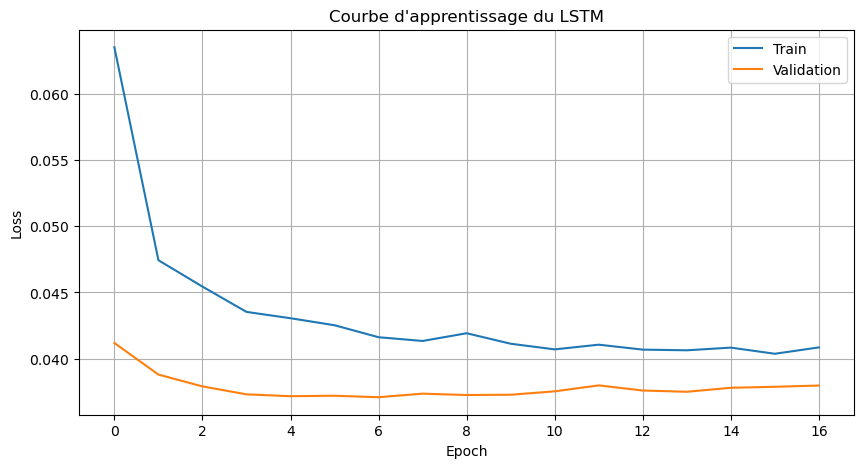

In [394]:
# ================================================================
#  Courbes d'apprentissage

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(

    history.history["loss"],

    label="Train"

)

plt.plot(

    history.history["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Courbe d'apprentissage du LSTM")

plt.legend()

plt.grid(True)

plt.show()

In [396]:
# ================================================================
# Cellule 14 : Prédictions


pred = model.predict(X_test)

pred = pred.flatten()

print(pred[:10])

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
[0.35853878 0.2018648  0.15260223 0.60075974 0.1968851  0.1732875
 0.18312646 0.18323357 0.24400969 0.2502161 ]


In [398]:
# ================================================================
# Cellule 15 : Dénormalisation
# ================================================================

pred_reelles = []

y_reelles = []

for i in range(len(meta_test)):

    station = meta_test.iloc[i]["Code Station"]
    produit = meta_test.iloc[i]["N° article"]

    scaler = series_normalisees[(station, produit)]["scaler"]

    y_true = scaler.inverse_transform(
        [[y_test[i]]]
    )[0,0]

    y_hat = scaler.inverse_transform(
        [[pred[i]]]
    )[0,0]

    y_reelles.append(y_true)
    pred_reelles.append(y_hat)

y_reelles = np.array(y_reelles)
pred_reelles = np.array(pred_reelles)

## 11. Évaluation

Les performances sont évaluées à l'aide des mêmes indicateurs que ceux utilisés pour les modèles Random Forest, XGBoost et SARIMA :

- MAE ;
- RMSE ;
- MAPE ;
- coefficient de détermination R².

Cette homogénéité permet une comparaison directe entre les différentes approches.

In [434]:
# ================================================================
# Cellule 16 : Evaluation finale
# ================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

mae_global = mean_absolute_error(y_reelles, pred_reelles)

rmse_global = np.sqrt(
    mean_squared_error(
        y_reelles,
        pred_reelles
    )
)

mape_global = mean_absolute_percentage_error(
    y_reelles,
    pred_reelles
) * 100

r2_global = r2_score(
    y_reelles,
    pred_reelles
)

print("="*60)
print("PERFORMANCES DU LSTM GLOBAL")
print("="*60)

print(f"MAE  : {mae_global:,.2f}")
print(f"RMSE : {rmse_global:,.2f}")
print(f"MAPE : {mape_global:.2f}%")
print(f"R²   : {r2_global:.4f}")

PERFORMANCES DU LSTM GLOBAL
MAE  : 7,972.59
RMSE : 13,471.25
MAPE : 41.91%
R²   : 0.7525


====================================================
EXPERIMENTATION 2
LSTM GLOBAL PAR PRODUIT
====================================================

### ESSENCE A0001

In [402]:
df_a0001 = df[df["N° article"]=="A0001"].copy()

print(df_a0001.shape)

(2580, 24)


In [404]:
#  Filtrage des couples

nb_mois = (
    df_a0001.groupby(
        ["Code Station","N° article"]
    )["quantite_mois"]
    .count()
    .reset_index(name="nb_mois")
)

couples_valides = nb_mois[
    nb_mois["nb_mois"]>=12
][["Code Station","N° article"]]

df1 = df_a0001.merge(
    couples_valides,
    on=["Code Station","N° article"],
    how="inner"
)

print("Dataset filtré :",df1.shape)

print()

print(
    "Nombre de couples :",
    df1[
        ["Code Station","N° article"]
    ].drop_duplicates().shape[0]
)

Dataset filtré : (2580, 24)

Nombre de couples : 71


In [406]:
df1["mois"] = pd.to_datetime(df1["mois"])

df1 = df1.sort_values(
    [
        "Code Station",
        "N° article",
        "mois"
    ]
)

df1.reset_index(
    drop=True,
    inplace=True
)

df1.head()

,Code Station,N° article,mois_periode,quantite_mois,nb_commandes,mois,annee,num_mois,trimestre,mois_sin,...,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,StationEncoded,ProduitEncoded
0,ST0001,A0001,2023-10,79000,4,2023-10-01,2023,10,4,-8.660254e-01,...,20000.0,95000.0,20000.0,65000.000000,68833.333333,57166.666667,39686.269666,1.1370,0,0
1,ST0001,A0001,2023-11,70000,4,2023-11-01,2023,11,4,-5.000000e-01,...,79000.0,80000.0,24000.0,59666.666667,74000.000000,62083.333333,34355.979586,0.9611,0,0
2,ST0001,A0001,2023-12,55000,4,2023-12-01,2023,12,4,-2.449294e-16,...,70000.0,20000.0,49000.0,56333.333333,68166.666667,65916.666667,31785.741038,0.8546,0,0
3,ST0001,A0001,2024-01,55000,5,2024-01-01,2024,1,1,5.000000e-01,...,55000.0,79000.0,56000.0,68000.000000,66500.000000,66416.666667,12124.355653,1.0238,0,0
4,ST0001,A0001,2024-02,105000,7,2024-02-01,2024,2,1,8.660254e-01,...,55000.0,70000.0,34000.0,60000.000000,59833.333333,66333.333333,8660.254038,0.9045,0,0


In [408]:
features = [

'StationEncoded',

'ProduitEncoded',

'annee',

'num_mois',

'trimestre',

'mois_sin',

'mois_cos',

'saison_benin',

'Lag_1',

'Lag_3',

'Lag_12',

'Rolling_3m',

'Rolling_6m',

'Rolling_12m',

'Rolling_Std_3m',

'ratio_tendance',

'nb_commandes'

]

target = "quantite_mois"

In [410]:
# Vérification des séries

resume = (
    df1
    .groupby(["Code Station","N° article"])
    .agg(
        debut=("mois","min"),
        fin=("mois","max"),
        observations=("quantite_mois","count")
    )
    .reset_index()
)

display(resume.head())

print()

print(resume["observations"].describe())

print()

print("Minimum :",resume["observations"].min())

print("Maximum :",resume["observations"].max())

print("Moyenne :",round(resume["observations"].mean(),2))

,Code Station,N° article,debut,fin,observations
0,ST0001,A0001,2023-10-01,2025-12-01,27
1,ST0002,A0001,2021-03-01,2025-12-01,58
2,ST0003,A0001,2021-03-01,2025-12-01,56
3,ST0004,A0001,2023-09-01,2025-12-01,28
4,ST0006,A0001,2021-01-01,2024-04-01,40



count    71.000000
mean     36.338028
std      16.133323
min      12.000000
25%      22.000000
50%      34.000000
75%      53.500000
max      60.000000
Name: observations, dtype: float64

Minimum : 12
Maximum : 60
Moyenne : 36.34


In [412]:
series_normalisees_ess = {}

for (station, produit), groupe in df1.groupby(
    ["Code Station","N° article"]
):

    groupe = groupe.sort_values("mois").copy()

    scaler = MinMaxScaler()

    groupe["quantite_norm"] = scaler.fit_transform(
        groupe[["quantite_mois"]]
    )

    series_normalisees_ess[(station,produit)] = {
        "data":groupe,
        "scaler":scaler
    }

print("Nombre de séries normalisées :",len(series_normalisees_ess))

Nombre de séries normalisées : 71


In [414]:
WINDOW_SIZE = 12

X_ess = []
y_ess = []

meta_ess = []

for (station, produit), infos in series_normalisees_ess.items():

    serie = infos["data"]["quantite_norm"].values

    dates = infos["data"]["mois"].values

    for i in range(len(serie) - WINDOW_SIZE):

        X_ess.append(
            serie[i:i+WINDOW_SIZE]
        )

        y_ess.append(
            serie[i+WINDOW_SIZE]
        )

        meta_ess.append({

            "Code Station":station,

            "N° article":produit,

            "Date":dates[i+WINDOW_SIZE]

        })

X_ess = np.array(X_ess)

y_ess = np.array(y_ess)

meta_ess = pd.DataFrame(meta_ess)

print("="*70)
print("JEU D'APPRENTISSAGE")
print("="*70)

print("Nombre de fenêtres :",len(X_ess))
print("Dimension X :",X_ess.shape)
print("Dimension y :",y_ess.shape)

JEU D'APPRENTISSAGE
Nombre de fenêtres : 1728
Dimension X : (1728, 12)
Dimension y : (1728,)


In [416]:
# Reshape pour le LSTM


X_ess = X_ess.reshape(

    X_ess.shape[0],

    X_ess.shape[1],

    1

)

print(X_ess.shape)

(1728, 12, 1)


In [418]:
ordre = np.argsort(meta_ess["Date"])

X_ess = X_ess[ordre]

y_ess = y_ess[ordre]

meta_ess = meta_ess.iloc[ordre].reset_index(drop=True)

split = int(len(X_ess)*0.80)

X_train_ess = X_ess[:split]
X_test_ess = X_ess[split:]

y_train_ess = y_ess[:split]
y_test_ess = y_ess[split:]

meta_train_ess = meta_ess.iloc[:split]
meta_test_ess = meta_ess.iloc[split:]

print("="*70)
print("TRAIN / TEST")
print("="*70)

print("Train :",X_train_ess.shape)

print("Test  :",X_test_ess.shape)

TRAIN / TEST
Train : (1382, 12, 1)
Test  : (346, 12, 1)


In [420]:
# MODELE LSTM

model_ess = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(WINDOW_SIZE,1)
    ),

    Dropout(0.20),

    LSTM(
        32
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])

model_ess.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model_ess.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                       │ (None, 12, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_21 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [422]:
# CALLBACKS

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5

)

history_ess = model_ess.fit(

    X_train_ess,

    y_train_ess,

    validation_data=(

        X_test_ess,

        y_test_ess

    ),

    epochs=100,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0592 - mae: 0.1824 - val_loss: 0.0391 - val_mae: 0.1453 - learning_rate: 0.0010
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0491 - mae: 0.1639 - val_loss: 0.0377 - val_mae: 0.1430 - learning_rate: 0.0010
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0469 - mae: 0.1590 - val_loss: 0.0371 - val_mae: 0.1411 - learning_rate: 0.0010
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0457 - mae: 0.1570 - val_loss: 0.0364 - val_mae: 0.1399 - learning_rate: 0.0010
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0440 - mae: 0.1524 - val_loss: 0.0359 - val_mae: 0.1384 - learning_rate: 0.0010
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0442 - mae: 0.1535 - val_loss: 0.0359 - val_mae: 0.1386 - learning_rate: 0.0010
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0429 - mae: 0.1515 - val_loss: 0.0359 - val_mae: 0.1361 - learning_rate: 0.0010
Epoch 

In [424]:
# ================================================================
# Cellule 12 : Sauvegarde du modèle
# ================================================================

model_ess.save("lstm_global_essence.keras")

print()

print("Modèle sauvegardé : lstm_global_essence.keras")


Modèle sauvegardé : lstm_global_essence.keras


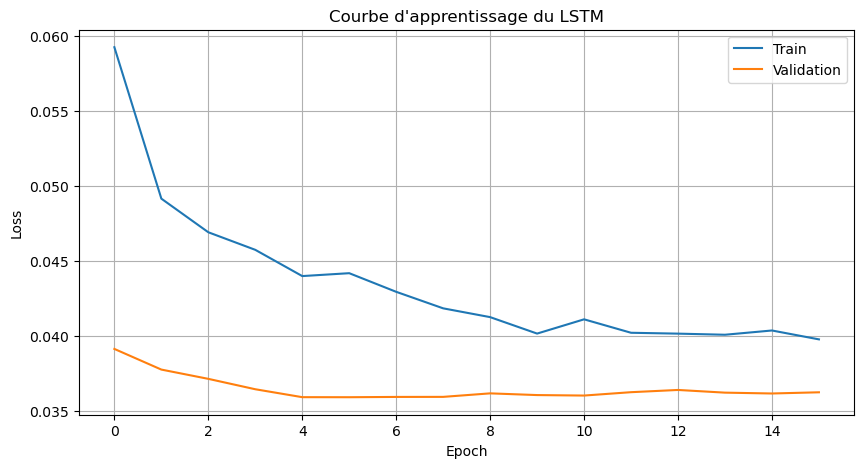

In [426]:
# ================================================================
# Cellule 13 : Courbes d'apprentissage
# ================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(

    history_ess.history["loss"],

    label="Train"

)

plt.plot(

    history_ess.history["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Courbe d'apprentissage du LSTM")

plt.legend()

plt.grid(True)

plt.show()

In [428]:
# ================================================================
# Cellule 14 : Prédictions
# ================================================================

pred = model_ess.predict(X_test_ess)

pred_ess = pred.flatten()

print(pred[:10])

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
[[0.27262682]
 [0.26125887]
 [0.18218583]
 [0.33416852]
 [0.37540105]
 [0.23840608]
 [0.34513375]
 [0.16213115]
 [0.31836206]
 [0.22845845]]


In [430]:
# ================================================================
# Cellule 15 : Dénormalisation
# ================================================================

pred_reelles_ess = []

y_reelles_ess = []

for i in range(len(meta_test_ess)):

    station = meta_test_ess.iloc[i]["Code Station"]
    produit = meta_test_ess.iloc[i]["N° article"]

    scaler_ess = series_normalisees_ess[(station, produit)]["scaler"]

    y_true = scaler_ess.inverse_transform(
        [[y_test_ess[i]]]
    )[0,0]

    y_hat = scaler_ess.inverse_transform(
        [[pred_ess[i]]]
    )[0,0]

    y_reelles_ess.append(y_true)
    pred_reelles_ess.append(y_hat)

y_reelles_ess = np.array(y_reelles_ess)
pred_reelles_ess = np.array(pred_reelles_ess)

In [432]:
# ================================================================
# Cellule 16 : Evaluation finale
# ================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

mae_ess = mean_absolute_error(y_reelles_ess, pred_reelles_ess)

rmse_ess = np.sqrt(
    mean_squared_error(
        y_reelles_ess,
        pred_reelles_ess
    )
)

mape_ess = mean_absolute_percentage_error(
    y_reelles_ess,
    pred_reelles_ess
) * 100

r2_ess = r2_score(
    y_reelles_ess,
    pred_reelles_ess
)

print("="*60)
print("PERFORMANCES DU LSTM GLOBAL ESSENCE")
print("="*60)

print(f"MAE  : {mae_ess:,.2f}")
print(f"RMSE : {rmse_ess:,.2f}")
print(f"MAPE : {mape_ess:.2f}%")
print(f"R²   : {r2_ess:.4f}")

PERFORMANCES DU LSTM GLOBAL ESSENCE
MAE  : 7,556.45
RMSE : 11,348.89
MAPE : 34.78%
R²   : 0.8865


### GASOIL A0002

In [436]:
df_a0002 = df[df["N° article"]=="A0002"].copy()

print(df_a0002.shape)

(2758, 24)


In [438]:
#  Filtrage des couples


nb_mois = (
    df_a0002.groupby(
        ["Code Station","N° article"]
    )["quantite_mois"]
    .count()
    .reset_index(name="nb_mois")
)

couples_valides = nb_mois[
    nb_mois["nb_mois"]>=12
][["Code Station","N° article"]]

df2 = df_a0002.merge(
    couples_valides,
    on=["Code Station","N° article"],
    how="inner"
)

print("Dataset filtré :",df2.shape)

print()

print(
    "Nombre de couples :",
    df2[
        ["Code Station","N° article"]
    ].drop_duplicates().shape[0]
)

Dataset filtré : (2758, 24)

Nombre de couples : 76


In [335]:
df2["mois"] = pd.to_datetime(df2["mois"])

df2 = df2.sort_values(
    [
        "Code Station",
        "N° article",
        "mois"
    ]
)

df2.reset_index(
    drop=True,
    inplace=True
)

df2.head()

,Code Station,N° article,mois_periode,quantite_mois,nb_commandes,mois,annee,num_mois,trimestre,mois_sin,...,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,StationEncoded,ProduitEncoded
0,ST0001,A0002,2023-10,109000,5,2023-10-01,2023,10,4,-8.660254e-01,...,90000.0,88000.0,15000.0,81000.000000,75000.000000,51666.666667,13892.443989,1.5677,0,1
1,ST0001,A0002,2023-11,86000,6,2023-11-01,2023,11,4,-5.000000e-01,...,109000.0,65000.0,22000.0,88000.000000,84500.000000,59500.000000,22068.076491,1.4790,0,1
2,ST0001,A0002,2023-12,85000,5,2023-12-01,2023,12,4,-2.449294e-16,...,86000.0,90000.0,23000.0,95000.000000,84166.666667,64833.333333,12288.205727,1.4653,0,1
3,ST0001,A0002,2024-01,85000,7,2024-01-01,2024,1,1,5.000000e-01,...,85000.0,109000.0,44000.0,93333.333333,87166.666667,70000.000000,13576.941236,1.3333,0,1
4,ST0001,A0002,2024-02,49000,5,2024-02-01,2024,2,1,8.660254e-01,...,85000.0,86000.0,30000.0,85333.333333,86666.666667,73416.666667,577.350269,1.1623,0,1


In [440]:
features = [

'StationEncoded',

'ProduitEncoded',

'annee',

'num_mois',

'trimestre',

'mois_sin',

'mois_cos',

'saison_benin',

'Lag_1',

'Lag_3',

'Lag_12',

'Rolling_3m',

'Rolling_6m',

'Rolling_12m',

'Rolling_Std_3m',

'ratio_tendance',

'nb_commandes'

]

target = "quantite_mois"

In [442]:
# Vérification des séries

resume = (
    df2
    .groupby(["Code Station","N° article"])
    .agg(
        debut=("mois","min"),
        fin=("mois","max"),
        observations=("quantite_mois","count")
    )
    .reset_index()
)

display(resume.head())

print()

print(resume["observations"].describe())

print()

print("Minimum :",resume["observations"].min())

print("Maximum :",resume["observations"].max())

print("Moyenne :",round(resume["observations"].mean(),2))

,Code Station,N° article,debut,fin,observations
0,ST0001,A0002,2023-10-01,2025-12-01,26
1,ST0002,A0002,2021-03-01,2025-12-01,55
2,ST0003,A0002,2021-04-01,2025-11-01,52
3,ST0004,A0002,2023-09-01,2025-11-01,27
4,ST0005,A0002,2024-01-01,2025-11-01,22



count    76.000000
mean     36.289474
std      16.054753
min      13.000000
25%      21.500000
50%      33.000000
75%      52.000000
max      60.000000
Name: observations, dtype: float64

Minimum : 13
Maximum : 60
Moyenne : 36.29


In [444]:
series_normalisees_gas = {}

for (station, produit), groupe in df2.groupby(
    ["Code Station","N° article"]
):

    groupe = groupe.sort_values("mois").copy()

    scaler = MinMaxScaler()

    groupe["quantite_norm"] = scaler.fit_transform(
        groupe[["quantite_mois"]]
    )

    series_normalisees_gas[(station,produit)] = {
        "data":groupe,
        "scaler":scaler
    }

print("Nombre de séries normalisées :",len(series_normalisees_gas))

Nombre de séries normalisées : 76


In [446]:
WINDOW_SIZE = 12

X_gas = []
y_gas = []

meta_gas = []

for (station, produit), infos in series_normalisees_gas.items():

    serie = infos["data"]["quantite_norm"].values

    dates = infos["data"]["mois"].values

    for i in range(len(serie) - WINDOW_SIZE):

        X_gas.append(
            serie[i:i+WINDOW_SIZE]
        )

        y_gas.append(
            serie[i+WINDOW_SIZE]
        )

        meta_gas.append({

            "Code Station":station,

            "N° article":produit,

            "Date":dates[i+WINDOW_SIZE]

        })

X_gas = np.array(X_gas)

y_gas = np.array(y_gas)

meta_gas = pd.DataFrame(meta_gas)

print("JEU D'APPRENTISSAGE")

print("Nombre de fenêtres :",len(X_gas))
print("Dimension X :",X_gas.shape)
print("Dimension y :",y_gas.shape)

JEU D'APPRENTISSAGE
Nombre de fenêtres : 1846
Dimension X : (1846, 12)
Dimension y : (1846,)


In [456]:
# Reshape pour le LSTM


X_gas = X_gas.reshape(

    X_gas.shape[0],

    X_gas.shape[1],

    1

)

print(X_gas.shape)

(1846, 12, 1)


In [460]:
ordre = np.argsort(meta_gas["Date"])

X_gas = X_gas[ordre]

y_gas = y_gas[ordre]

meta_gas = meta_gas.iloc[ordre].reset_index(drop=True)

split = int(len(X_gas)*0.80)

X_train_gas = X_gas[:split]
X_test_gas = X_gas[split:]

y_train_gas = y_gas[:split]
y_test_gas = y_gas[split:]

meta_train_gas = meta_gas.iloc[:split]
meta_test_gas = meta_gas.iloc[split:]

print("TRAIN / TEST")

print("Train :",X_train_gas.shape)

print("Test  :",X_test_gas.shape)

TRAIN / TEST
Train : (1476, 12, 1)
Test  : (370, 12, 1)


In [462]:
# MODELE LSTM

model_gas = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(WINDOW_SIZE,1)
    ),

    Dropout(0.20),

    LSTM(
        32
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )

])

model_gas.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model_gas.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                       │ (None, 12, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_23 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [464]:
# CALLBACKS

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-5

)

history_gas = model_gas.fit(

    X_train_gas,

    y_train_gas,

    validation_data=(

        X_test_gas,

        y_test_gas

    ),

    epochs=100,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0564 - mae: 0.1733 - val_loss: 0.0430 - val_mae: 0.1521 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0466 - mae: 0.1575 - val_loss: 0.0411 - val_mae: 0.1485 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0447 - mae: 0.1534 - val_loss: 0.0401 - val_mae: 0.1479 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0432 - mae: 0.1510 - val_loss: 0.0393 - val_mae: 0.1465 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0434 - mae: 0.1515 - val_loss: 0.0391 - val_mae: 0.1447 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0429 - mae: 0.1494 - val_loss: 0.0390 - val_mae: 0.1458 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0430 - mae: 0.1504 - val_loss: 0.0386 - val_mae: 0.1443 - learning_rate: 0.0010
Epoch 

In [466]:
# ================================================================
# Cellule 12 : Sauvegarde du modèle
# ================================================================

model_gas.save("lstm_global_gasoil.keras")

print()

print("Modèle sauvegardé : lstm_global_gasoil.keras")


Modèle sauvegardé : lstm_global_gasoil.keras


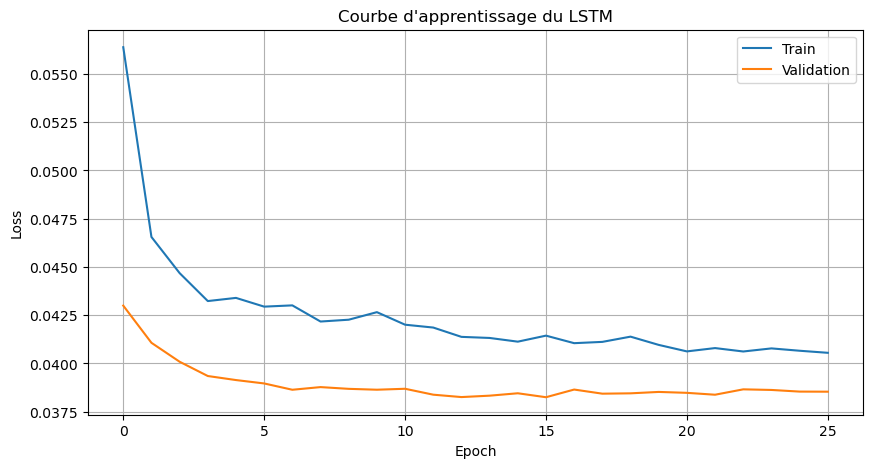

In [468]:
# Courbes d'apprentissage

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(

    history_gas.history["loss"],

    label="Train"

)

plt.plot(

    history_gas.history["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Courbe d'apprentissage du LSTM")

plt.legend()

plt.grid(True)

plt.show()

In [470]:
# ================================================================
# Cellule 14 : Prédictions
# ================================================================

pred = model_gas.predict(X_test_gas)

pred_gas = pred.flatten()

print(pred_gas[:10])

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
[0.23424569 0.19342068 0.38124788 0.28007564 0.28466755 0.3944702
 0.2547257  0.25216866 0.32501256 0.31554204]


In [472]:
# ================================================================
# Cellule 15 : Dénormalisation
# ================================================================

pred_reelles_gas = []

y_reelles_gas = []

for i in range(len(meta_test_gas)):

    station = meta_test_gas.iloc[i]["Code Station"]
    produit = meta_test_gas.iloc[i]["N° article"]

    scaler_gas = series_normalisees_gas[(station, produit)]["scaler"]

    y_true = scaler_gas.inverse_transform(
        [[y_test_gas[i]]]
    )[0,0]

    y_hat = scaler_gas.inverse_transform(
        [[pred_gas[i]]]
    )[0,0]

    y_reelles_gas.append(y_true)
    pred_reelles_gas.append(y_hat)

y_reelles_gas = np.array(y_reelles_gas)
pred_reelles_gas = np.array(pred_reelles_gas)

In [474]:
# ================================================================
# Cellule 16 : Evaluation finale
# ================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

mae_gas = mean_absolute_error(y_reelles_gas, pred_reelles_gas)

rmse_gas = np.sqrt(
    mean_squared_error(
        y_reelles_gas,
        pred_reelles_gas
    )
)

mape_gas = mean_absolute_percentage_error(
    y_reelles_gas,
    pred_reelles_gas
) * 100

r2_gas = r2_score(
    y_reelles_gas,
    pred_reelles_gas
)

print("="*60)
print("PERFORMANCES DU LSTM GLOBAL GASOIL")
print("="*60)

print(f"MAE  : {mae_gas:,.2f}")
print(f"RMSE : {rmse_gas:,.2f}")
print(f"MAPE : {mape_gas:.2f}%")
print(f"R²   : {r2_gas:.4f}")

PERFORMANCES DU LSTM GLOBAL GASOIL
MAE  : 7,834.09
RMSE : 12,387.14
MAPE : 43.87%
R²   : 0.5309


In [479]:
# ================================================================
# RÉSUMÉ DES MODÈLES LSTM
# ================================================================

resume_lstm = pd.DataFrame({

    "Modèle":[
        "LSTM Global",
        "LSTM Essence",
        "LSTM Gasoil"
    ],

    "MAE":[
        mae_global,
        mae_ess,
        mae_gas
    ],

    "RMSE":[
        rmse_global,
        rmse_ess,
        rmse_gas
    ],

    "MAPE":[
        mape_global,
        mape_ess,
        mape_gas
    ],

    "R²":[
        r2_global,
        r2_ess,
        r2_gas
    ]

})

resume_lstm = resume_lstm.sort_values("MAPE")

print("RÉSUMÉ DES PERFORMANCES LSTM")

print(
    resume_lstm.round(
        {
            "MAE":2,
            "RMSE":2,
            "MAPE":2,
            "R²":4
        }
    )
)

resume_lstm.to_csv(
    "resume_modeles_LSTM.csv",
    index=False
)

print()
print(" resume_modeles_LSTM.csv sauvegardé")

RÉSUMÉ DES PERFORMANCES LSTM
         Modèle      MAE      RMSE   MAPE      R²
1  LSTM Essence  7556.45  11348.89  34.78  0.8865
0   LSTM Global  7972.59  13471.25  41.91  0.7525
2   LSTM Gasoil  7834.09  12387.14  43.87  0.5309

 resume_modeles_LSTM.csv sauvegardé


# 📊 Synthèse finale des résultats – Modèles LSTM

## 1. Objectif de l’expérimentation

L’objectif de cette phase était d’évaluer la performance de modèles **LSTM (Long Short-Term Memory)** dans un contexte de prévision des séries temporelles de ventes mensuelles, selon trois configurations :

- 🔹 Modèle global (toutes les données confondues)
- 🔹 Modèle spécifique Gasoil
- 🔹 Modèle spécifique Essence

L’idée principale était de tester si la spécialisation par produit améliore la qualité des prévisions par rapport à un modèle global unique.

---

## 2. Résultats obtenus

| Modèle         | MAE     | RMSE     | MAPE (%) | R²     |
|----------------|----------|----------|----------|--------|
| LSTM Essence   | **7556.45** | **11348.89** | **34.78** | **0.8865** |
| LSTM Global    | 7972.59  | 13471.25 | 41.91 | 0.7525 |
| LSTM Gasoil    | 7834.09  | 12387.14 | 43.87 | 0.5309 |

---

## 3. Analyse comparative

### 🔹 Meilleur modèle global
Le modèle **LSTM Essence** obtient les meilleures performances globales :

- Meilleur **MAE** et **RMSE**
- Meilleur **MAPE (34.78%)**
- Meilleur **R² (0.8865)**

👉 Cela indique que les séries "Essence" sont **plus régulières et mieux apprenables** par un LSTM.

---

### 🔹 Modèle global (moins performant)
Le modèle global présente des performances plus faibles :

- Erreurs plus élevées (MAE et RMSE)
- Perte de précision (MAPE élevé)
- R² plus faible (0.75)

👉 Cela confirme qu’un modèle unique peine à capturer les dynamiques hétérogènes des produits.

---

### 🔹 Cas du Gasoil
Le modèle Gasoil est le plus instable :

- R² faible (0.53)
- MAPE élevé (43.87%)

👉 Cela suggère :
- forte variabilité des ventes
- possible bruit dans les données
- difficulté pour LSTM à apprendre une dynamique stable

---

## 4. Conclusion scientifique

### ✔️ Apports principaux

- La **segmentation par produit améliore globalement la performance**
- Le LSTM est **adapté aux séries relativement stables (ex : Essence)**
- Le modèle global est **moins performant que les modèles spécialisés**

---

### ⚠️ Limites observées

- Le LSTM est sensible à :
  - la qualité des données
  - la longueur des séries
  - la variabilité forte (cas Gasoil)
- Certaines séries restent difficiles à modéliser même avec segmentation

---

## 5. Conclusion générale

👉 Le modèle LSTM est **viable pour la prévision des ventes**, mais :

- Il fonctionne mieux sur des segments homogènes
- La segmentation améliore la précision
- Un modèle global seul n’est pas optimal

💡 **Recommandation finale :**
Une approche hybride est préférable :
> segmentation (produit ou comportement) + modèles dédiés (LSTM ou XGBoost)

---